In [2]:
import math
from time import time

import torch
import torch.nn as nn
import torch.nn.functional as F

import torchvision
from torchvision import transforms
from torchsummary import summary

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from tqdm import tqdm


device = 'mps' if torch.backends.mps.is_available() else 'cpu'

<img src="http://present5.com/presentation/20143288_415358496/image-8.jpg" width=500, height=400>

In [3]:
transform = transforms.Compose( 
    [transforms.ToTensor()]
) #transforms нужен чтобы аггрегировать датасеты (сюда же можно положить аугментации)

trainset = torchvision.datasets.MNIST(root='./data', train=True, 
                                      download=True, transform=transform) #передает transforms в класс
trainloader = torch.utils.data.DataLoader(trainset, batch_size=4,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.MNIST(root='./data', train=False,
                                     download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=4,
                                         shuffle=False, num_workers=2)

classes = tuple(str(i) for i in range(10))

In [6]:
trainloader.dataset.train_data[0], trainloader.dataset.train_data[0].shape

/Users/timmiakov/Dev/hse-ml-course/.venv/lib/python3.13/site-packages/torchvision/datasets/mnist.py:76: UserWarning: train_data has been renamed data
  warnings.warn("train_data has been renamed data")


(tensor([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
            0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
         [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
            0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
         [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
            0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
         [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
            0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
         [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
            0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
         [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,  18,
           18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,   0,   0],
         [  0,   0,   0,   0,   0,

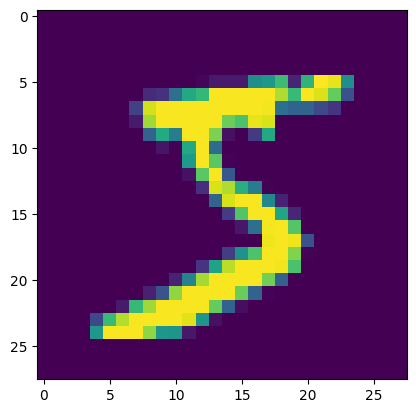

In [5]:
numpy_img = trainloader.dataset.train_data[0].numpy()
plt.imshow(numpy_img);

In [ ]:
class SimpleConvNet(nn.Module):
    def __init__(self):
        super(SimpleConvNet, self).__init__()

        self.conv1 = nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5) #сверточный слой
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5)
        self.fc1 = nn.Linear(4 * 4 * 16, 120)  # !!!
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 4 * 4 * 16) #вытягиваем в линию
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [ ]:
model = SimpleConvNet()

summary(model, (1, 28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 6, 24, 24]             156
         MaxPool2d-2            [-1, 6, 12, 12]               0
            Conv2d-3             [-1, 16, 8, 8]           2,416
         MaxPool2d-4             [-1, 16, 4, 4]               0
            Linear-5                  [-1, 120]          30,840
            Linear-6                   [-1, 84]          10,164
            Linear-7                   [-1, 10]             850
Total params: 44,426
Trainable params: 44,426
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.04
Params size (MB): 0.17
Estimated Total Size (MB): 0.22
----------------------------------------------------------------


In [7]:
# выбираем функцию потерь
loss_fn = torch.nn.CrossEntropyLoss()

# выбираем алгоритм оптимизации и learning_rate
learning_rate = 1e-4
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
losses = []

In [8]:
model.to(device)

SimpleConvNet(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=256, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

  0%|          | 0/2 [00:00<?, ?it/s]

[1,  2000] loss: 1.099
[1,  4000] loss: 0.447
[1,  6000] loss: 0.339
[1,  8000] loss: 0.274
[1, 10000] loss: 0.234
[1, 12000] loss: 0.211
[1, 14000] loss: 0.168


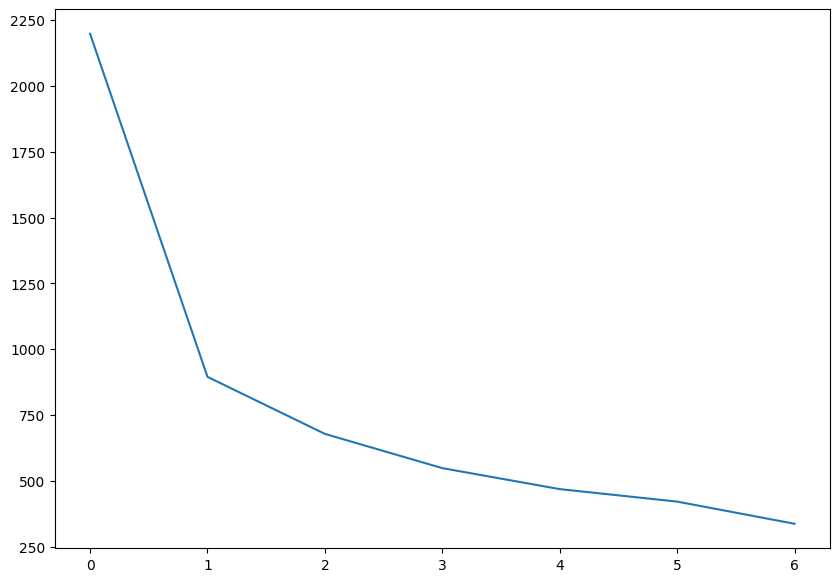

 50%|█████     | 1/2 [00:41<00:41, 41.48s/it]

[2,  2000] loss: 0.147
[2,  4000] loss: 0.141
[2,  6000] loss: 0.127
[2,  8000] loss: 0.101
[2, 10000] loss: 0.117
[2, 12000] loss: 0.113
[2, 14000] loss: 0.103


100%|██████████| 2/2 [01:26<00:00, 43.10s/it]

Обучение закончено


In [9]:
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(1, 1, 1)


for epoch in tqdm(range(2)):

    running_loss = 0.0
    for i, batch in enumerate(trainloader):
        # так получаем текущий батч
        X_batch, y_batch = batch
        
        # обнуляем веса
        optimizer.zero_grad()

        # forward + backward + optimize
        y_pred = model(X_batch.to(device))
        loss = loss_fn(y_pred, y_batch.to(device))
        loss.backward()
        optimizer.step()

        # выведем текущий loss
        running_loss += loss.item()
        # выведем качество каждые 2000 батчей
        if i % 2000 == 1999:
            print('[%d, %5d] loss: %.3f' %
                  (epoch + 1, i + 1, running_loss / 2000))
            losses.append(running_loss)
            running_loss = 0.0

    ax.clear()
    ax.plot(np.arange(len(losses)), losses)
    plt.show()

print('Обучение закончено')

In [10]:
class_correct = list(0. for i in range(10))
class_total = list(0. for i in range(10))

with torch.no_grad():
    for data in testloader:
        images, labels = data
        y_pred = model(images.to(device))
        _, predicted = torch.max(y_pred, 1)
        
        c = (predicted.cpu().detach() == labels)
        for i in range(4):
            label = labels[i]
            class_correct[label] += c[i].item()
            class_total[label] += 1


for i in range(10):
    print('Accuracy of %5s : %2d %%' % (
        classes[i], 100 * class_correct[i] / class_total[i]))

Accuracy of     0 : 98 %
Accuracy of     1 : 99 %
Accuracy of     2 : 97 %
Accuracy of     3 : 97 %
Accuracy of     4 : 97 %
Accuracy of     5 : 97 %
Accuracy of     6 : 96 %
Accuracy of     7 : 97 %
Accuracy of     8 : 97 %
Accuracy of     9 : 96 %


### Аугментация

In [11]:
train_raw = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=None)
classes = train_raw.classes
print("Классы:", classes)

Классы: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


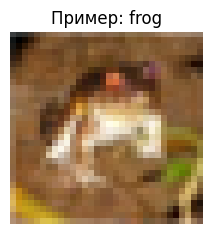

In [12]:
img, label = train_raw[0]

plt.figure(figsize=(2.5,2.5))
plt.imshow(img)

plt.axis("off")
plt.title(f"Пример: {classes[label]}")
plt.show()

In [13]:
def show_images_grid(images, titles=None, cols=4, suptitle=None, figsize=(10,8)):
    rows = math.ceil(len(images)/cols)
    plt.figure(figsize=figsize)
    
    for i, im in enumerate(images):
        ax = plt.subplot(rows, cols, i+1)
        
        if isinstance(im, torch.Tensor):
            im_np = im.permute(1,2,0).cpu().numpy()
            im_np = np.clip(im_np, 0, 1)
            plt.imshow(im_np)
        else:
            plt.imshow(im)
            plt.axis("off")
    
        if titles:
            ax.set_title(titles[i], fontsize=10)
    
        if suptitle:
            plt.suptitle(suptitle, y=0.99, fontsize=14)
    
    plt.tight_layout()
    plt.show()

def visualize_augmentations(pil_image, transform, n=8, cols=4, title=""):
    images = []
    for _ in range(n):
        aug = transform(pil_image)
        images.append(aug)

    show_images_grid(images, cols=cols, suptitle=title)

In [14]:
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD = (0.2470, 0.2435, 0.2616)

def denormalize(t):
    mean = torch.tensor(CIFAR10_MEAN)[:, None, None]
    std = torch.tensor(CIFAR10_STD)[:, None, None]
    return t * std + mean

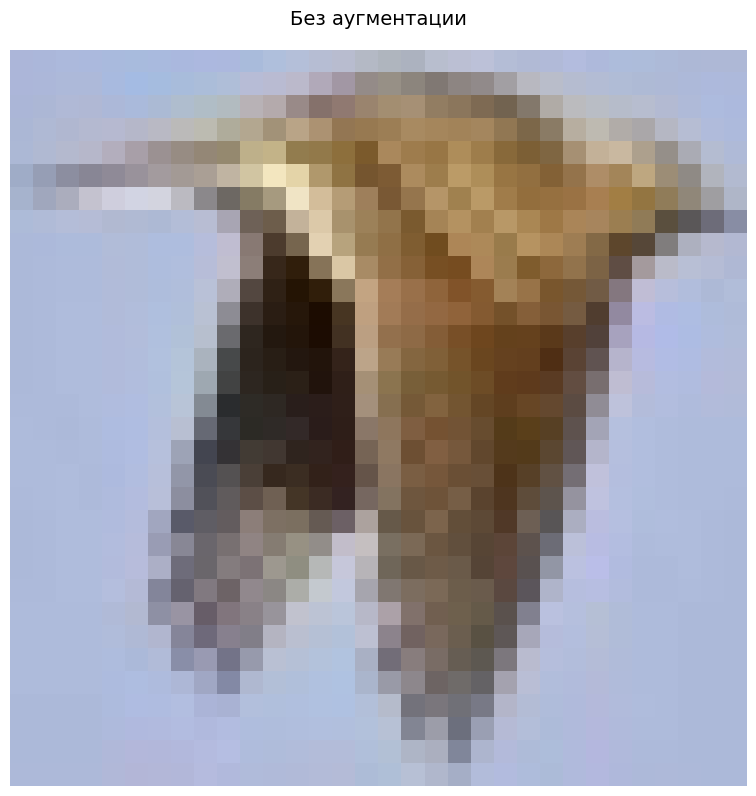

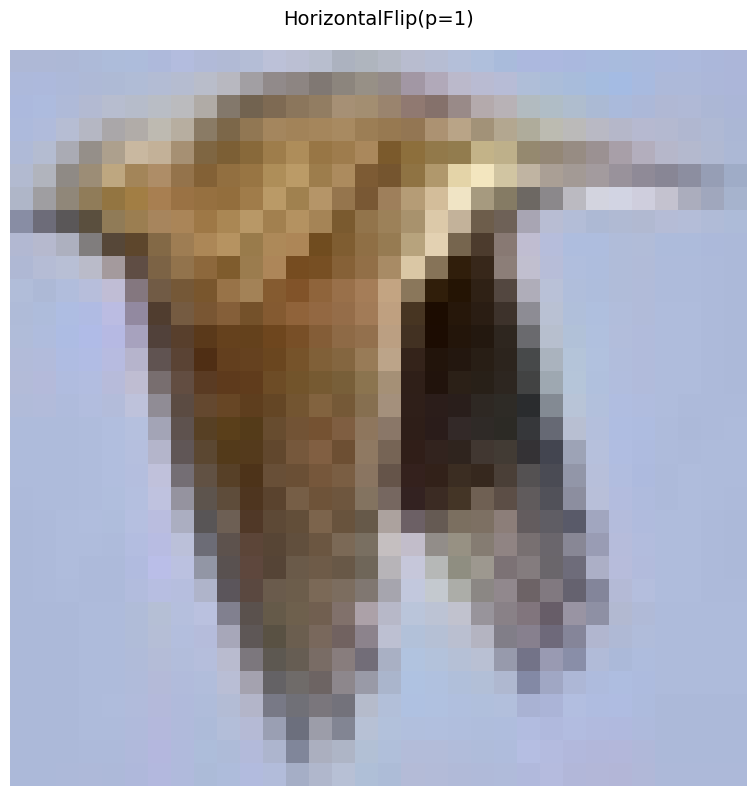

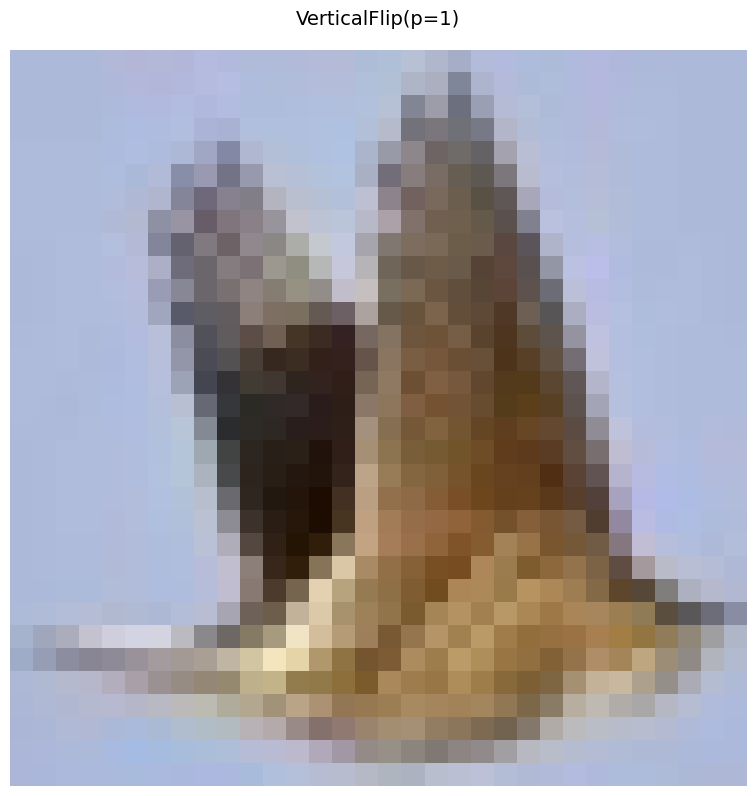

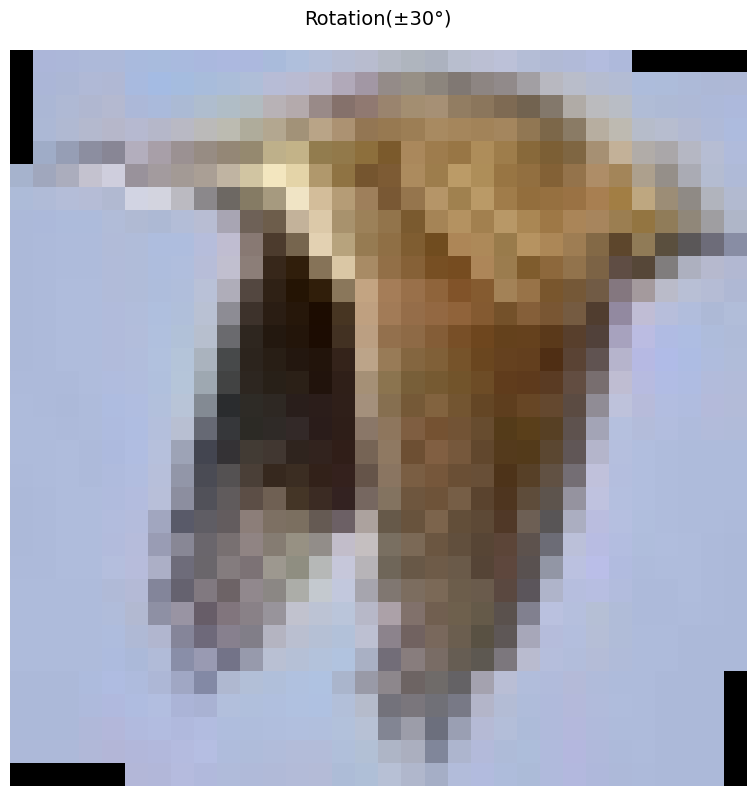

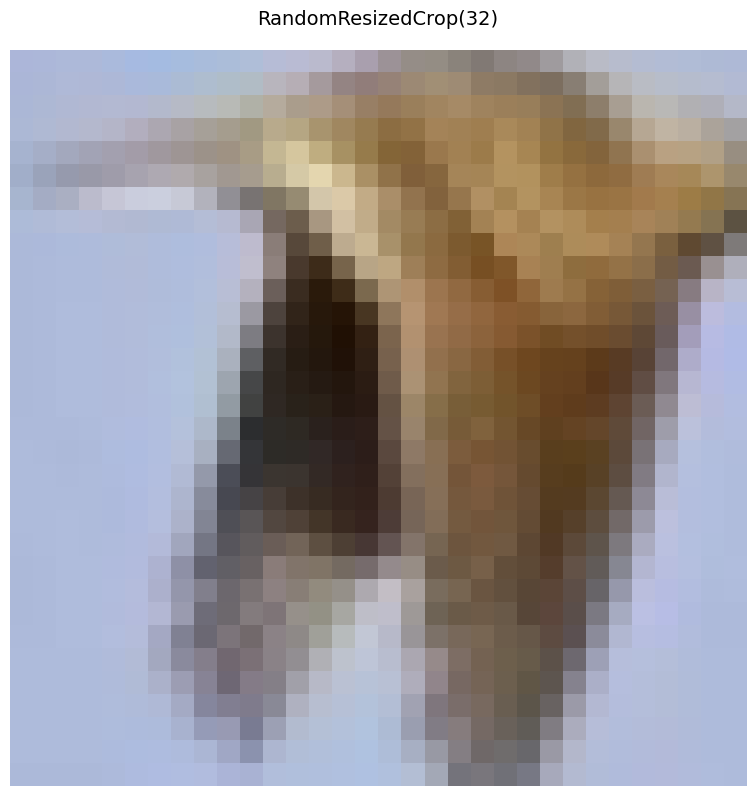

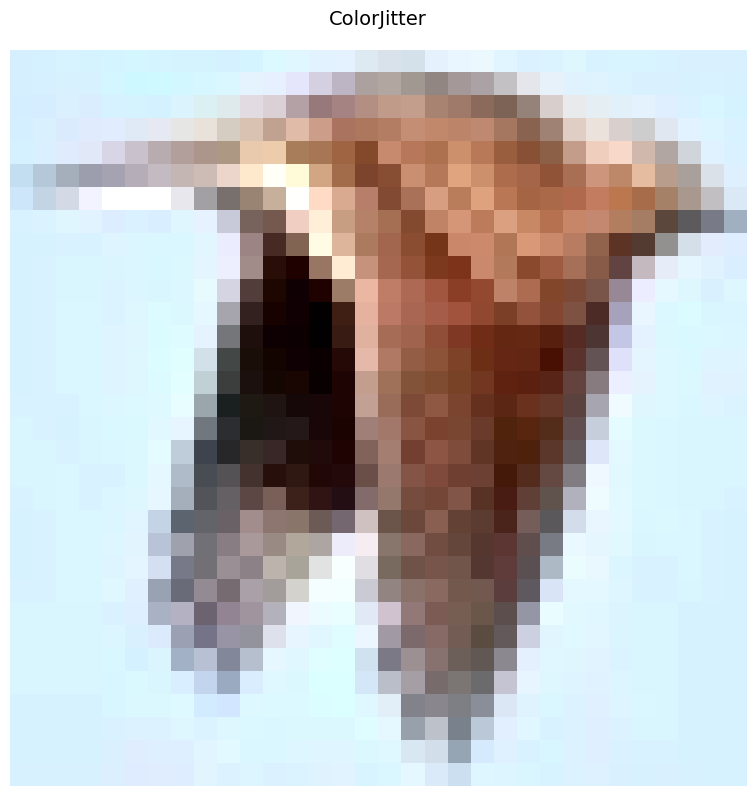

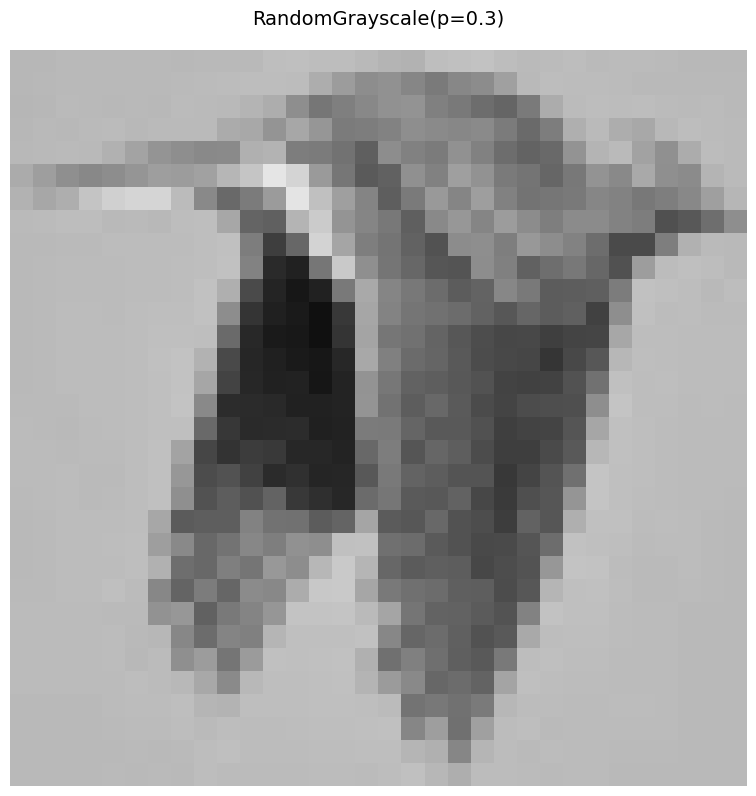

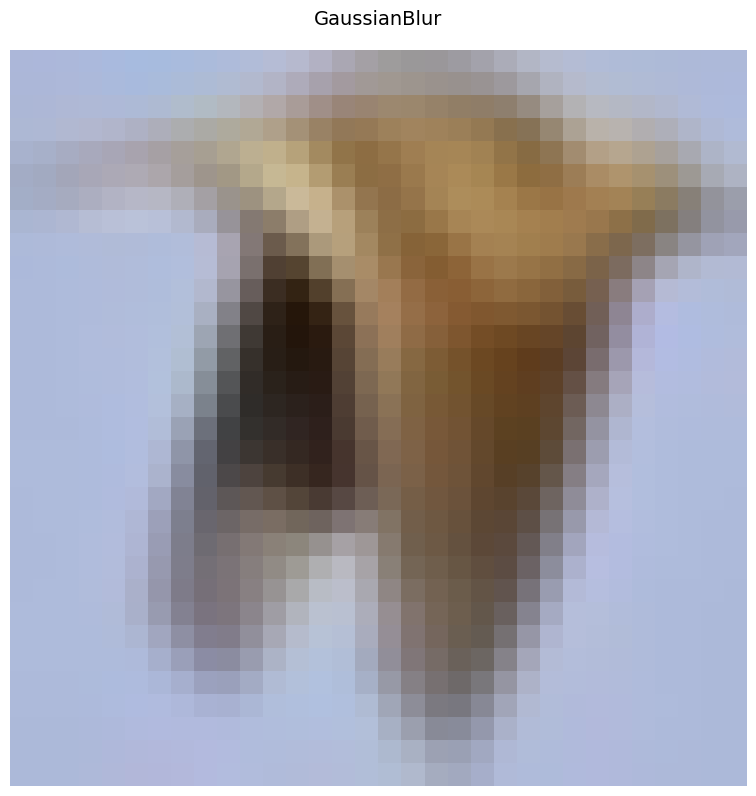

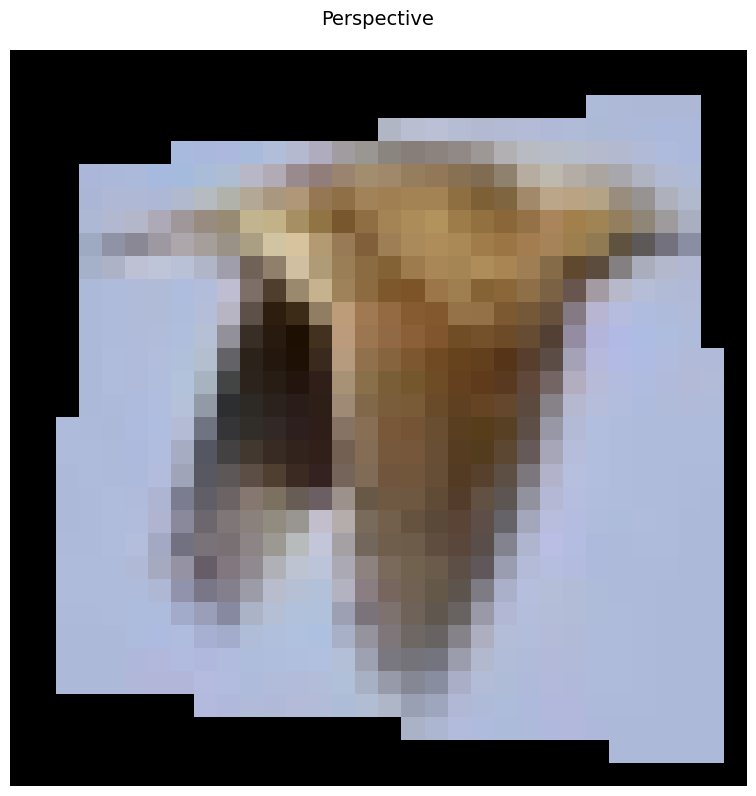

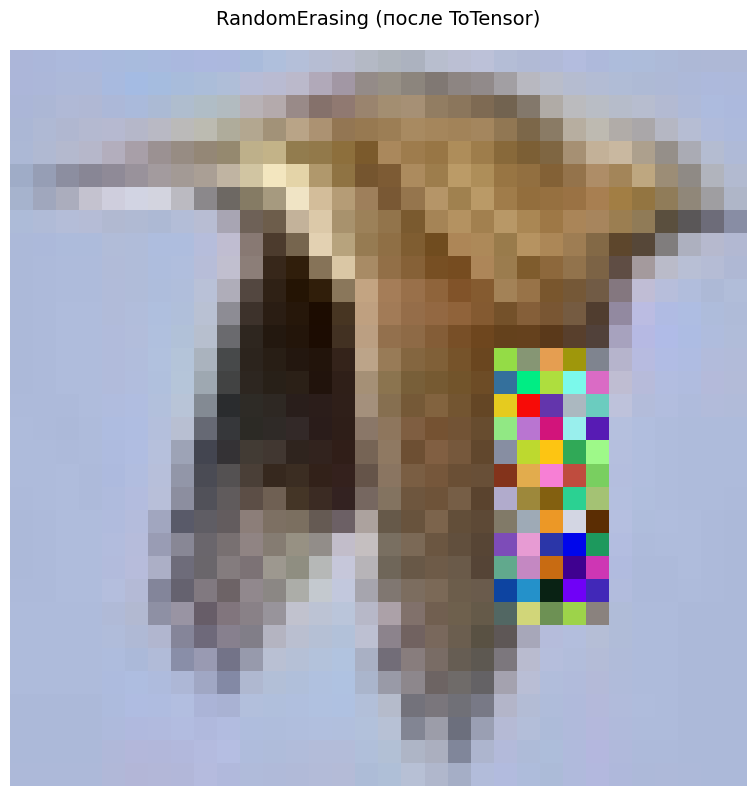

In [15]:
augs  = {
    "Без аугментации": transforms.Compose([
        lambda x: x
    ]),
    "HorizontalFlip(p=1)": transforms.Compose([
        transforms.RandomHorizontalFlip(p=1.0)
    ]),
    "VerticalFlip(p=1)": transforms.Compose([
        transforms.RandomVerticalFlip(p=1.0)
    ]),
    "Rotation(±30°)": transforms.Compose([
        transforms.RandomRotation(degrees=30)
    ]),
    "RandomResizedCrop(32)": transforms.Compose([
        transforms.RandomResizedCrop(size=32, scale=(0.6, 1.0), ratio=(0.75, 1.333))
    ]),
    "ColorJitter": transforms.Compose([
        transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.05)
    ]),
    "RandomGrayscale(p=0.3)": transforms.Compose([
        transforms.RandomGrayscale(p=0.3)
    ]),
    "GaussianBlur": transforms.Compose([
        transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0))
    ]),
    "Perspective": transforms.Compose([
        transforms.RandomPerspective(distortion_scale=0.4, p=1.0)
    ]),
    "RandomErasing (после ToTensor)": transforms.Compose([
        transforms.ToTensor(),
        transforms.RandomErasing(p=1.0, scale=(0.02, 0.2), ratio=(0.3, 3.3), value='random'),
        transforms.ToPILImage()
    ]),
}

sample_img, sample_label = train_raw[123]
for name, aug in augs.items():
    visualize_augmentations(sample_img, aug, n=1, cols=1, title=name)

In [16]:
train_transform_diff = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomApply([transforms.ColorJitter(0.4,0.4,0.4,0.1)], p=0.8),
    transforms.RandomGrayscale(p=0.1),
    transforms.RandomResizedCrop(size=32, scale=(0.6, 1.0), ratio=(0.75, 1.333)),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.15), ratio=(0.3, 3.3), value='random'),
])

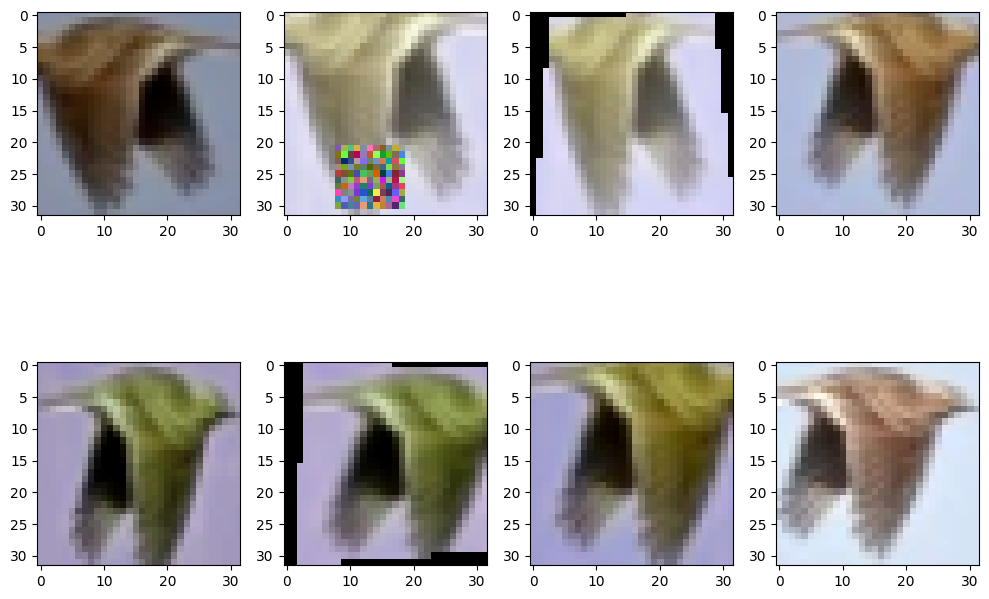

In [17]:
def visualize_pipeline_on_sample(pil_image, transform, n=8):
    imgs = []
    for _ in range(n):
        t = transform(pil_image)
        t_vis = denormalize(t).clamp(0,1)
        imgs.append(t_vis)
    
    show_images_grid(imgs, cols=4)

visualize_pipeline_on_sample(sample_img, train_transform_diff, n=8)

### Потреним с аугментацией и без

In [18]:
train_transform_base = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

train_transform_diff = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomApply([transforms.ColorJitter(0.4,0.4,0.4,0.1)], p=0.8),
    transforms.RandomGrayscale(p=0.1),
    transforms.RandomResizedCrop(size=32, scale=(0.6, 1.0), ratio=(0.75, 1.333)),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.15), ratio=(0.3, 3.3), value='random'),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

In [19]:
train_base = torchvision.datasets.CIFAR10(root='./data', train=True, download=False, transform=train_transform_base)
train_aug = torchvision.datasets.CIFAR10(root='./data', train=True, download=False, transform=train_transform_diff)

test_ds = torchvision.datasets.CIFAR10(root='./data', train=False, download=False, transform=test_transform)


batch_size = 128
num_workers = 2

train_base_loader = torch.utils.data.DataLoader(train_base, batch_size=batch_size, shuffle=True, num_workers=num_workers)
train_aug_loader = torch.utils.data.DataLoader(train_aug, batch_size=batch_size, shuffle=True, num_workers=num_workers)
test_loader = torch.utils.data.DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers)

In [30]:
class SmallCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1), # 32x32
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2), # 16x16

            nn.Conv2d(64, 128, 3, padding=1), # 16x16
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                  # 8x8
            
            nn.Conv2d(128, 256, 3, padding=1),# 8x8
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                  # 4x4
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256*4*4, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [31]:
def accuracy(logits, y):
    preds = logits.argmax(dim=1)
    return (preds == y).float().mean().item()

In [32]:
def train_one_epoch(model, loader, optimizer, criterion, device, max_batches=None):
    model.train()
    running_loss = 0.0
    running_acc = 0.0
    total = 0
    for _, (x, y) in enumerate(loader):
    
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
    
        batch_size = x.size(0)
        running_loss += loss.item() * batch_size
        running_acc += (logits.argmax(1) == y).sum().item()
        
        total += batch_size
        
    return running_loss / total, running_acc / total

@torch.no_grad()
def evaluate(model, loader, criterion, device, max_batches=None):
    model.eval()
    running_loss = 0.0
    running_acc = 0.0
    total = 0
    for _, (x, y) in enumerate(loader):
        
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        
        batch_size = x.size(0)
        running_loss += loss.item() * batch_size
        running_acc += (logits.argmax(1) == y).sum().item()
        
        total += batch_size
        
    return running_loss/total, running_acc/total

In [33]:
def fit_model(train_loader, test_loader, epochs=5, lr=1e-3, max_train_batches=150, max_eval_batches=None, seed=42):

    model = SmallCNN(num_classes=10).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    
    history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}
    for ep in tqdm(range(1, epochs+1)):
        
        t0 = time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device, max_batches=max_train_batches)
        te_loss, te_acc = evaluate(model, test_loader, criterion, device, max_batches=max_eval_batches)
        dt = time() - t0
        
        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["test_loss"].append(te_loss)
        history["test_acc"].append(te_acc)
        print(f"Эпоха {ep:2d}: train_loss={tr_loss:.4f} train_acc={tr_acc:.4f} | test_loss={te_loss:.4f} test_acc={te_acc:.4f} | {dt:.1f}s")
    
    return model, history


In [34]:
epochs = 10
max_train_batches = 600
max_eval_batches = None

print("Модель A: без аугментации")
model_base, hist_base = fit_model(train_base_loader, test_loader, epochs=epochs, lr=1e-3,
max_train_batches=max_train_batches, max_eval_batches=max_eval_batches, seed=42)

print("\nМодель B: с аугментацией")
model_aug, hist_aug = fit_model(train_aug_loader, test_loader, epochs=epochs, lr=1e-3,
max_train_batches=max_train_batches, max_eval_batches=max_eval_batches, seed=43)

Модель A: без аугментации


 10%|█         | 1/10 [00:32<04:55, 32.83s/it]

Эпоха  1: train_loss=1.3881 train_acc=0.4962 | test_loss=1.1497 test_acc=0.6020 | 32.8s


 20%|██        | 2/10 [01:05<04:21, 32.69s/it]

Эпоха  2: train_loss=0.9704 train_acc=0.6558 | test_loss=0.9008 test_acc=0.6856 | 32.6s


...

Эпоха  8: train_loss=1.1154 train_acc=0.6086 | test_loss=0.8174 test_acc=0.7124 | 32.2s


 90%|█████████ | 9/10 [04:49<00:32, 32.20s/it]

Эпоха  9: train_loss=1.0866 train_acc=0.6176 | test_loss=0.7558 test_acc=0.7422 | 32.2s


100%|██████████| 10/10 [05:22<00:00, 32.21s/it]

Эпоха 10: train_loss=1.0590 train_acc=0.6307 | test_loss=0.8005 test_acc=0.7250 | 32.2s


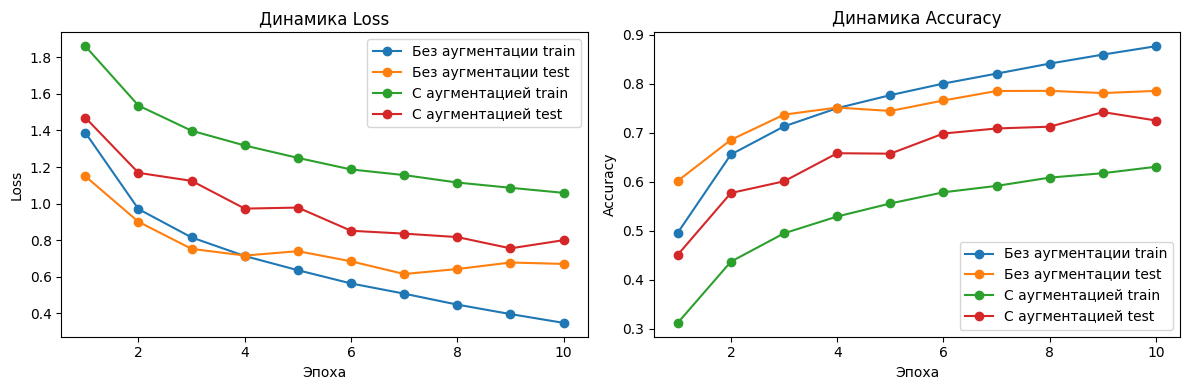

In [35]:
def plot_history(h1, h2, labels=("Без аугментации","С аугментацией")):

    epochs = range(1, len(h1["train_loss"])+1)
    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    plt.plot(epochs, h1["train_loss"], "-o", label=f"{labels[0]} train")
    plt.plot(epochs, h1["test_loss"], "-o", label=f"{labels[0]} test")
    plt.plot(epochs, h2["train_loss"], "-o", label=f"{labels[1]} train")
    plt.plot(epochs, h2["test_loss"], "-o", label=f"{labels[1]} test")
    plt.xlabel("Эпоха")
    plt.ylabel("Loss")
    plt.legend()
    plt.title("Динамика Loss")

    plt.subplot(1,2,2)
    plt.plot(epochs, h1["train_acc"], "-o", label=f"{labels[0]} train")
    plt.plot(epochs, h1["test_acc"], "-o", label=f"{labels[0]} test")
    plt.plot(epochs, h2["train_acc"], "-o", label=f"{labels[1]} train")
    plt.plot(epochs, h2["test_acc"], "-o", label=f"{labels[1]} test")
    plt.xlabel("Эпоха")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.title("Динамика Accuracy")
    plt.tight_layout()
    plt.show()

plot_history(hist_base, hist_aug)

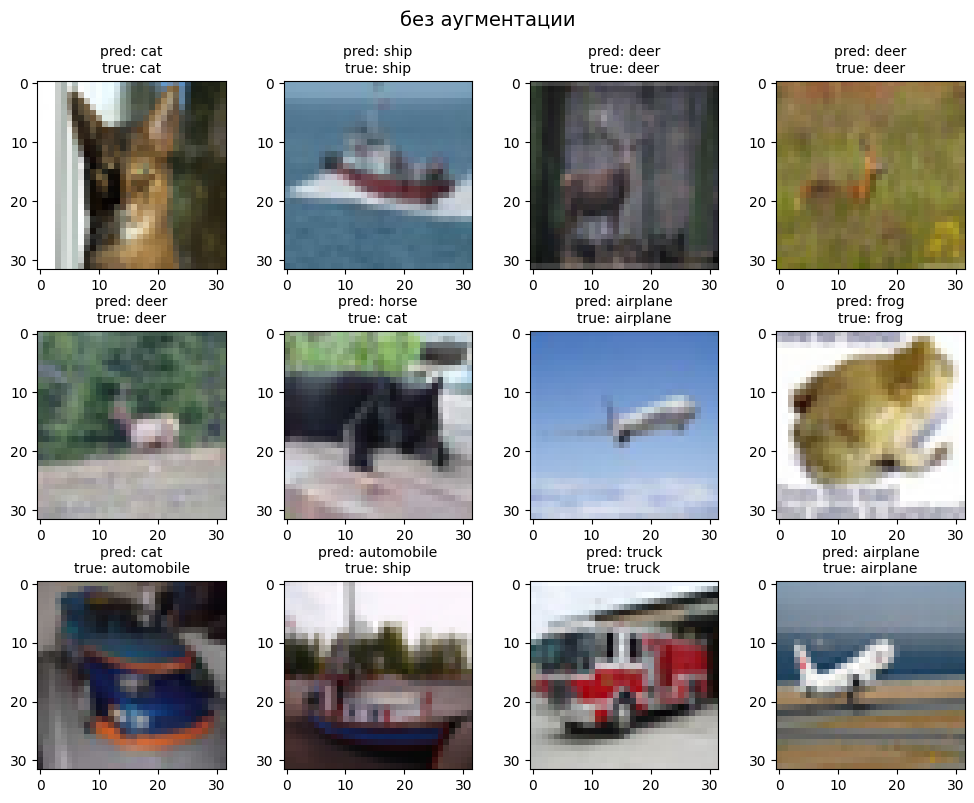

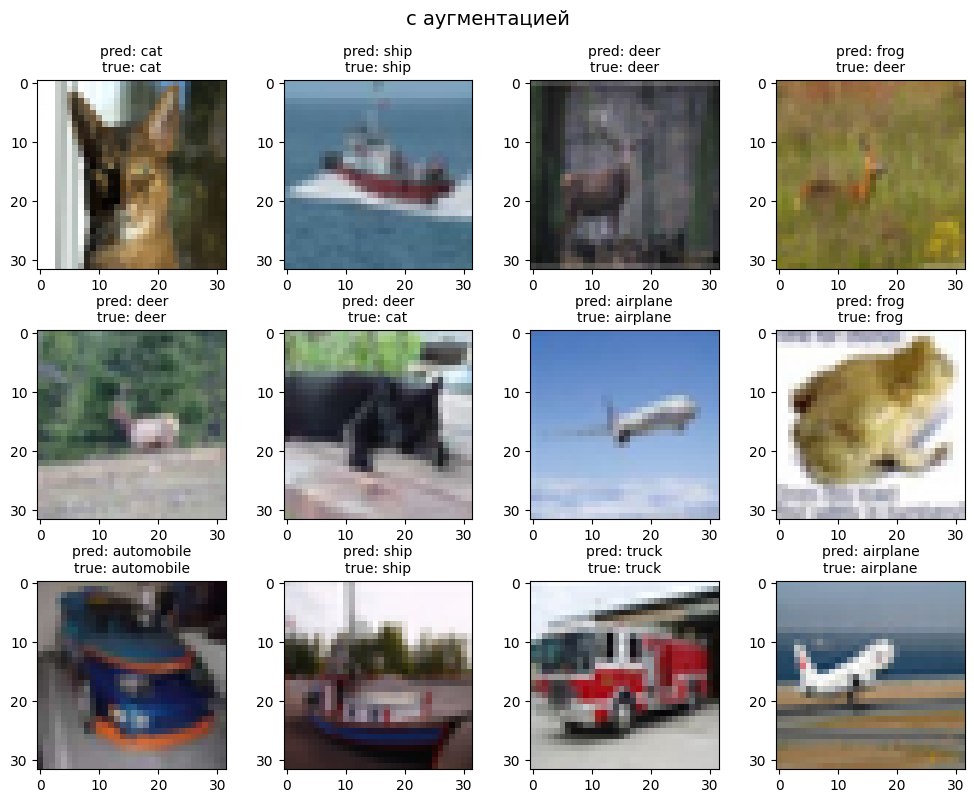

In [38]:
@torch.no_grad()
def show_predictions(idxs, model, dataset, suptitle, n=12):
    model.eval()
    ims, titles = [], []
    
    for i in idxs:
        x, y = dataset[i]

        x_vis = denormalize(x).clamp(0,1)
        logits = model(x.unsqueeze(0).to(device))
        pred = logits.argmax(1).item()
        ims.append(x_vis.cpu())
        titles.append(f"pred: {classes[pred]}\ntrue: {classes[y]}")
    
    show_images_grid(ims, titles=titles, cols=4, suptitle=suptitle)

idxs = np.random.choice(len(test_ds), size=12, replace=False)
show_predictions(idxs, model_base, test_ds, suptitle='без аугментации', n=12)
show_predictions(idxs, model_aug, test_ds, suptitle='с аугментацией', n=12)